In [1]:
#PROBLEM #1
import sqlite3 as sq
import pandas as pd

con = sq.connect("/Users/arnavchaturvedi/opioid.db")
sql = con.cursor()
population = pd.read_sql("select * from population", con)
annual = pd.read_sql("select * from annual", con)
land = pd.read_sql("select * from land", con)

#Find areas with missing data
annual[annual["countyfips"] == "NA"]
annual[(annual["countyfips"] == "NA") & (annual["BUYER_STATE"] !="PR")]

#Fix Montgomery county FIPS code
edit = (annual["BUYER_STATE"] == "AR") & (annual["BUYER_COUNTY"] == "MONTGOMERY")
annual.loc[edit, "countyfips"] = "05097"

#Remove rows with missing county data
annual = annual[annual["BUYER_COUNTY"] !="NA"]

#Build land_area table with countyfips column name
land_area = land[["Areaname", "STCOU", "LND110210D"]].rename(columns={"STCOU": "countyfips"})

#Left join population with land based on countyfips
county_info = population.merge(land_area, on="countyfips", how="left")

#checks
print(len(land)) #expect 3198
print(len(land_area)) #expect 3198
print(len(county_info)) #expect 28265
print(len(population)) #expect match of county_info

con.close()

3198
3198
28265
28265


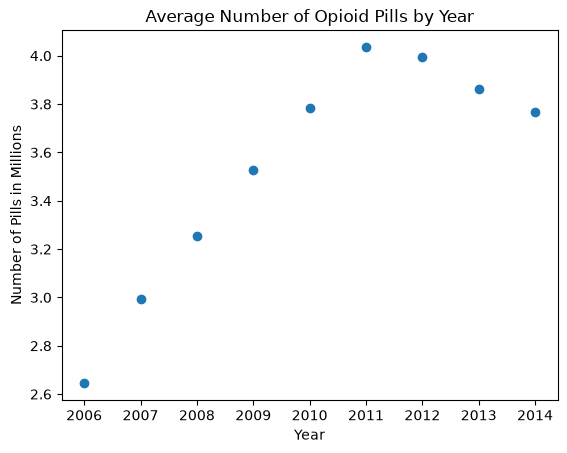

In [2]:
#PROBLEM 2
import matplotlib.pyplot as plt

#Bring in the data set
df=pd.read_csv("/Users/arnavchaturvedi/county_annual.csv")

#Plot is dosage in millions so add in another column
df["Pills_Millions"] = df["DOSAGE_UNIT"] / 1_000_000

#Calculate averages
yearly_avg = df.groupby("year")["Pills_Millions"].mean().reset_index()

#Create plot
plt.scatter(yearly_avg["year"], yearly_avg["Pills_Millions"])
plt.xlabel("Year")
plt.ylabel("Number of Pills in Millions")
plt.title("Average Number of Opioid Pills by Year")
plt.show()


In [3]:
#PROBLEM 4
!pip install rpy2
import os
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'

import rpy2
import rpy2.rinterface as ri
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

In [4]:
#Run R code
ro.r('''
setwd("/Users/arnavchaturvedi")
library(tidyverse)

#add in csv files
Populaton = read.csv("county_pop_arcos.csv")
Annual = read.csv("county_annual.csv")
Land = read.csv("land_area.csv")

#Find areas with missing data
Annual = Annual %>% filter(!is.na(BUYER_COUNTY))

#Fix Montgomery county FIPS code
Annual = Annual %>% mutate(countyfips = case_when(
  BUYER_STATE == "AR" 
  & BUYER_COUNTY == "MONTGOMERY" 
  ~ as.character("05097"), TRUE ~ as.character(countyfips)))

#Remove rows with missing county data
Annual = Annual %>% filter(!is.na(countyfips))

#Build land_area table and rename countyfips column
Land_area = Land %>% select(Areaname, STCOU, LND110210D)
Land_area = Land_area %>% rename(countyfips = STCOU)

#Left join population with land based on countyfips
County_info = left_join(Populaton, Land_area, by = "countyfips")
''')

#Convert dataset to pandas dataframe
with localconverter(ro.default_converter + pandas2ri.converter):
    county_info_py = ro.conversion.rpy2py(ro.r['County_info'])

#check
print(len(county_info_py)) #expect 28265

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
28265
